In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/retail-sales-prediction-and-demand-forecasting/white.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/blue.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/red.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/train.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/test.csv
/kaggle/input/retail-sales-prediction-and-demand-forecasting/yellow.csv


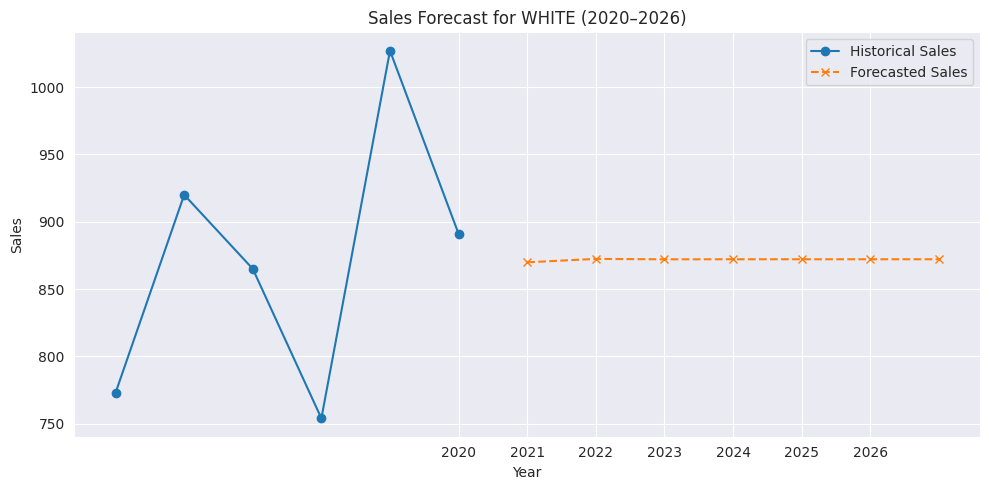

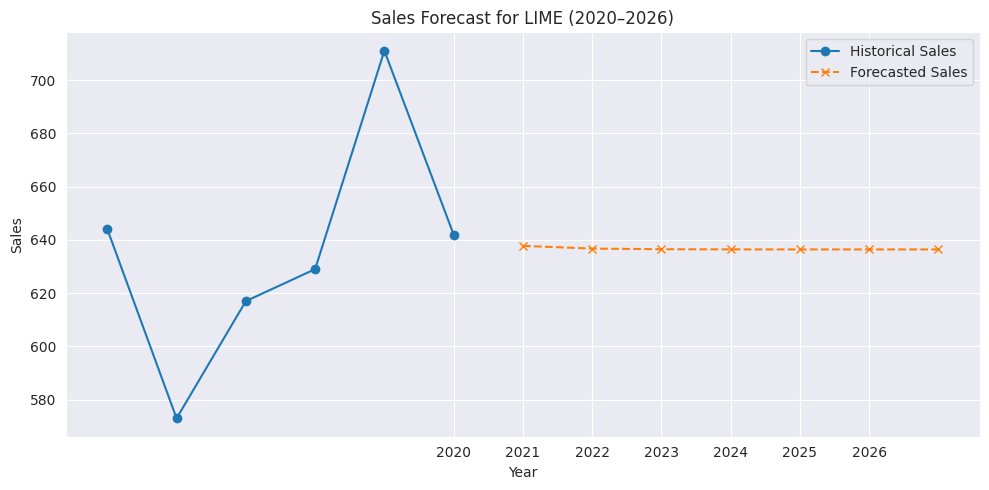

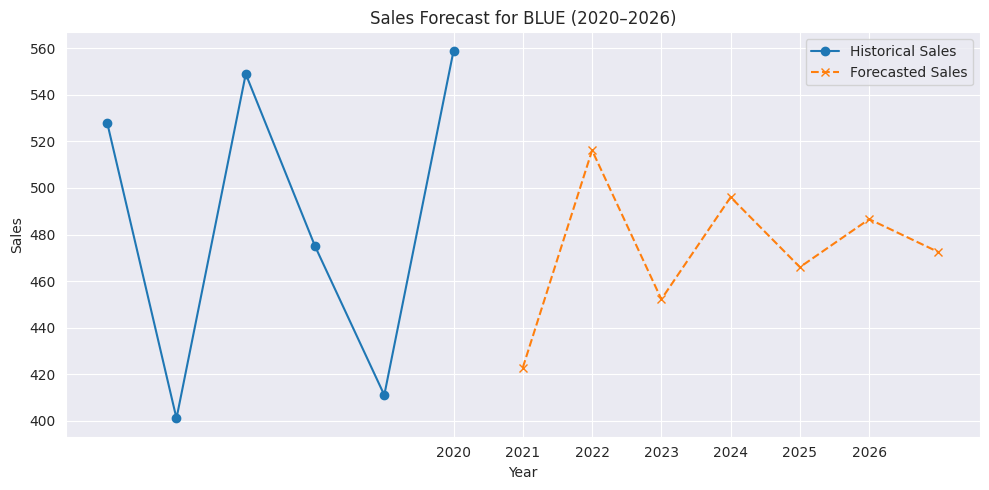

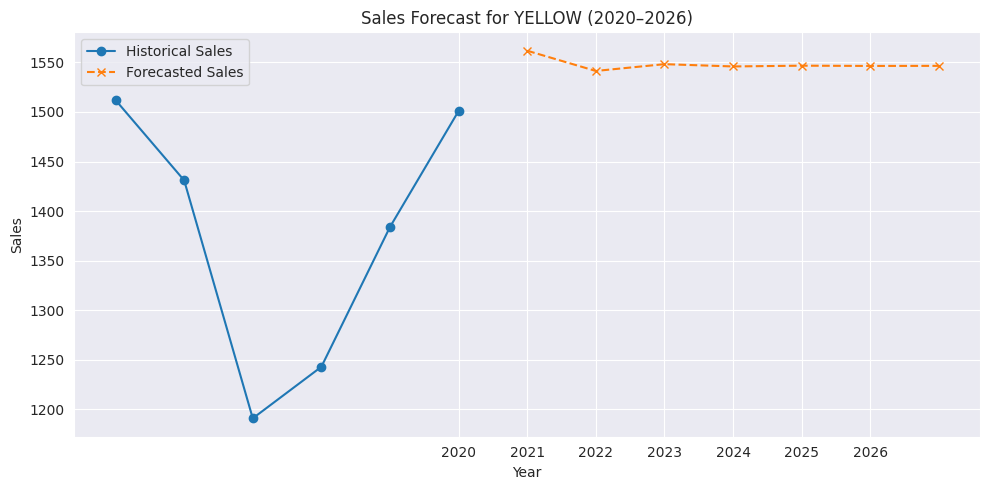

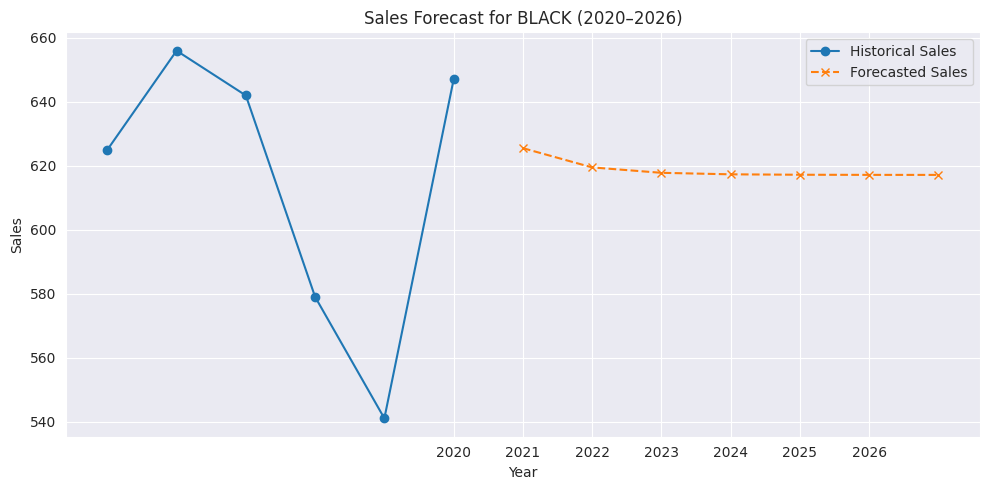

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")
sns.set_style('darkgrid')

# Load data (replace with your path if needed)
train = pd.read_csv('/kaggle/input/retail-sales-prediction-and-demand-forecasting/train.csv')

# Ensure Year column exists
if 'Year' not in train.columns:
    train['Year'] = pd.to_datetime(train['sales date']).dt.year

# Function to forecast sales using ARIMA for a given color
def forecast_sales_arima(color, train_df):
    color_data = train_df[train_df['ITEM_COLOR'] == color]
    
    # Use only data from 2015 onward
    color_data = color_data[color_data['Year'] >= 2015]

    if color_data['Year'].nunique() < 2:
        print(f"Skipping {color}: Not enough data (need at least 2 years)")
        return

    # Aggregate by year
    yearly_sales = color_data.groupby('Year')['SALES'].sum()
    
    # Fit ARIMA model
    model = ARIMA(yearly_sales, order=(1, 1, 1))
    model_fit = model.fit()
    
    forecast_steps = 7  # for 2020–2026
    forecast = model_fit.forecast(steps=forecast_steps)
    
    forecast_years = list(range(yearly_sales.index.max() + 1, yearly_sales.index.max() + 1 + forecast_steps))
    
    # Combine actual and forecasted
    plt.figure(figsize=(10, 5))
    plt.plot(yearly_sales.index, yearly_sales.values, label='Historical Sales', marker='o')
    plt.plot(forecast_years, forecast, label='Forecasted Sales', linestyle='--', marker='x')
    
    plt.title(f"Sales Forecast for {color} (2020–2026)")
    plt.xlabel("Year")
    plt.ylabel("Sales")
    plt.legend()
    plt.xticks(np.arange(2020, 2027, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Get unique ITEM_COLOR values
unique_colors = train['ITEM_COLOR'].dropna().unique()

# Run forecast for each color
for color in unique_colors:
    forecast_sales_arima(color, train)
